In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
def data_generator(n = 50 , noise = 10.0) : 
    np.random.seed(42)
    X = np.linspace(-10 , 10 , n)
    R_w1 = 5
    R_w0 = 3
    noise = np.random.randn(n) * noise # returns NDarray
    Y = R_w1 * X + R_w0 + noise
    return X , Y

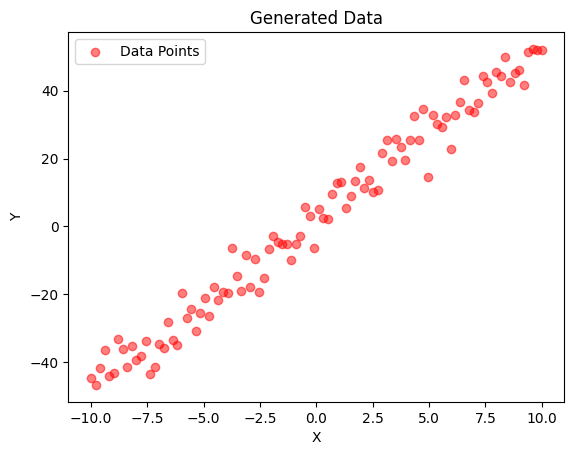

In [3]:
X , Y = data_generator(100 , 5)

plt.scatter(X , Y , c = "red" , alpha=0.5 ,label = "Data Points" )
plt.title("Generated Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [4]:
def h1_w(x , w) :
    return w[0] + w[1] * x

def h_w(x, w):
    x = np.c_[np.ones(len(x)) , x]
    return x.dot(w) 

def LR_closed(X,Y) :

    X_b = np.c_[np.ones((len(X), 1)), X] 
    w = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)
    return w 

W = LR_closed(X , Y) 
print(f"w1 : {W[1]:.2f} , w0 : {W[0]:.2f}")
    


w1 : 5.03 , w0 : 2.48


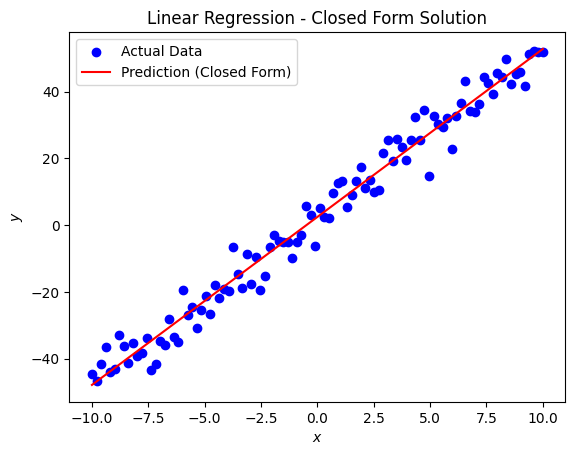

In [5]:
y_pred = h1_w(X, W)

plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Prediction (Closed Form)')
plt.title("Linear Regression - Closed Form Solution")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()


In [6]:
def LR_closed_GD( X , Y , itration = 1000 , eta = 0.05 ) :
    w_init = [ 0 , 0 ]
    m = len(X)
    for _ in range(itration) :
        gradient_w0 = np.sum(h1_w(X, w_init) - Y) / m
        gradient_w1 = np.sum((h1_w(X, w_init) - Y) * X) / m
        w_init[0] -= eta * gradient_w0
        w_init[1] -= eta * gradient_w1
    return w_init


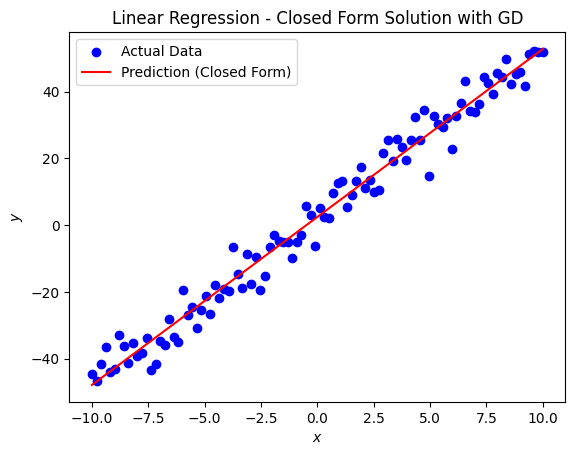

In [7]:
W = LR_closed_GD( X , Y )
y_pred = h1_w(X, W)

plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Prediction (Closed Form)')
plt.title("Linear Regression - Closed Form Solution with GD")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()

In [8]:
def make_poly_feature(X , d) :
    for i in range(2,d+1) :
        X = np.c_[ X , X**i ]
    X = np.c_[np.ones(len(X)) , X ]
    return X 
       


In [9]:
def PolyR_closed(X , Y) :
    W = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(Y)
    return W

def pred_y_poly(X , W) :
    y = X.dot(W)
    return y

X_poly = make_poly_feature(X , 1)
W_poly = PolyR_closed(X_poly , Y)
Y_poly = pred_y_poly(X_poly , W_poly)


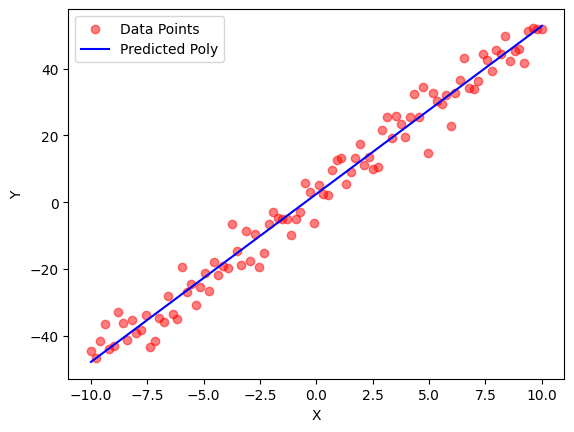

In [10]:

plt.scatter(X , Y , c = "red" , alpha=0.5 ,  label = "Data Points")
plt.plot(X , Y_poly , c = "blue" , label = "Predicted Poly")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


In [11]:
def MSE( x , w , y ) :
   x = np.c_[np.ones((len(x), 1)), x] 
   return np.sum(((x.dot(w) - y) ** 2)) / len(y) 

In [12]:
def RMSE(x , w , y) :
    return np.sqrt(MSE(x , w , y))

In [13]:
def MAE ( x , w , y ) :
    x = np.c_[np.ones((len(x), 1)), x] 
    return np.sum(abs((x.dot(w) - y))) / len(y) 

In [14]:
def R2 (x , w , y) :
    x = np.c_[np.ones((len(x), 1)), x] 
    SSres = np.sum((x.dot(w) - y) ** 2)
    SStot = np.sum((y - y.mean()) ** 2)
    return 1 - (SSres/SStot)
     

# Comparing GD and Closed Form of Linear Regression 

In [15]:
W_closedform = LR_closed(X , Y)
W_GD = LR_closed_GD(X , Y)

# comparing W
print(f'''
W's from GD : 
bias : {W_GD[0] :.3f}
W1 : {W_GD[1] :.3f}
----------------------
W's from Closed Form : 
bias : {W_closedform[0] :.3f}
W1 : {W_closedform[1] :.3f}''')


W's from GD : 
bias : 2.481
W1 : 5.034
----------------------
W's from Closed Form : 
bias : 2.481
W1 : 5.034


In [16]:
print("Closed Form:")
print("MSE:", MSE(X, W_closedform, Y))
print("RMSE:", RMSE(X, W_closedform, Y))
print("R2:", R2(X, W_closedform, Y))

print("\nGradient Descent:")
print("MSE:", MSE(X, W_GD, Y))
print("RMSE:", RMSE(X, W_GD, Y))
print("R2:", R2(X, W_GD, Y))

Closed Form:
MSE: 20.372617837451955
RMSE: 4.513603642041684
R2: 0.9769098571739901

Gradient Descent:
MSE: 20.372617837451955
RMSE: 4.513603642041684
R2: 0.9769098571739901


## Effect of Learning Rate on Gradient Descent

The learning rate (`eta`) controls the size of each update in Gradient Descent.

In this experiment, we test different learning rates and compare their effect on
the model's performance.

We will evaluate each model using:

- MSE
- RMSE
- R²

The main questions are:

1. Does a very small learning rate make training slower?
2. Does a larger learning rate improve convergence?
3. Can a learning rate that is too large make Gradient Descent unstable?
4. Which learning rate gives the best performance?

In [17]:
eta = [0.001, 0.02, 0.5]

for e in eta:
    W_GD = LR_closed_GD(X, Y, eta=e)

    mse = MSE(X, W_GD, Y)
    rmse = RMSE(X, W_GD, Y)
    mae = MAE(X, W_GD, Y)
    r2 = R2(X, W_GD, Y)

    print(f"eta = {e}")
    print(f"MSE  = {mse:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"R²   = {r2:.4f}")
    print("-" * 30)

eta = 0.001
MSE  = 21.2047
RMSE = 4.6049
MAE  = 3.6391
R²   = 0.9760
------------------------------
eta = 0.02
MSE  = 20.3726
RMSE = 4.5136
MAE  = 3.5748
R²   = 0.9769
------------------------------
eta = 0.5
MSE  = nan
RMSE = nan
MAE  = nan
R²   = nan
------------------------------


c:\Users\sherv\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\sherv\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\sherv\AppData\Local\Temp\ipykernel_23728\3905027289.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  w_init[1] -= eta * gradient_w1


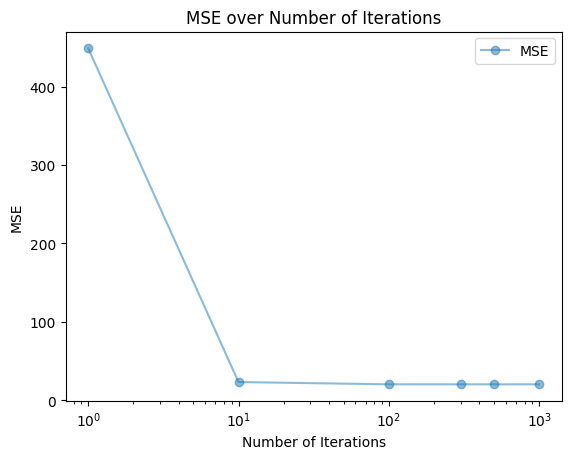

In [18]:
MSE_his_iteration = []
iterations = [1, 10, 100, 300, 500, 1000]

for itr in iterations:
    wgd = LR_closed_GD(X, Y, itration=itr)
    MSE_his_iteration.append(MSE(X, wgd, Y))

plt.plot(
    iterations,
    MSE_his_iteration,
    alpha=0.5,
    marker="o",
    label="MSE"
)

plt.title("MSE over Number of Iterations")
plt.xlabel("Number of Iterations")
plt.ylabel("MSE")
plt.xscale("log")
plt.legend()
plt.show()




# Test Model

testing my model with a real dataset to see the accuracy and then i will compare it to Scikit-learn model

In [19]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

x = data.data
y = data.target

In [20]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [21]:
x.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [22]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [23]:
x.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

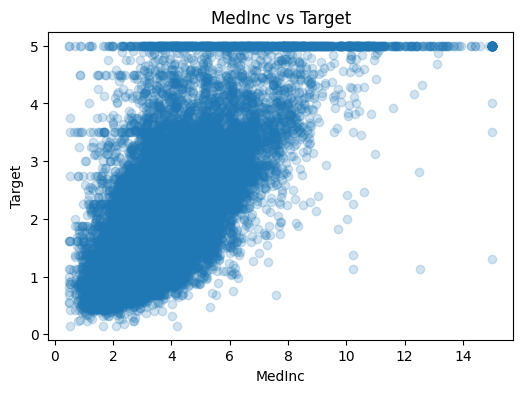

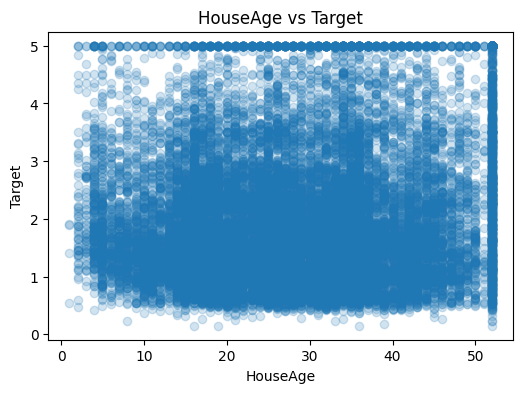

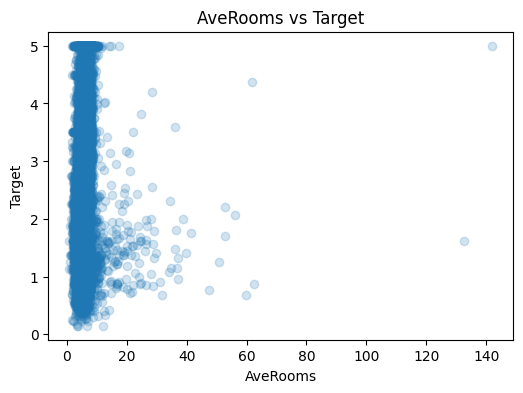

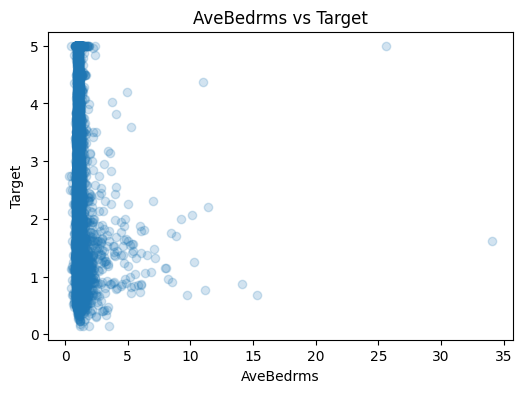

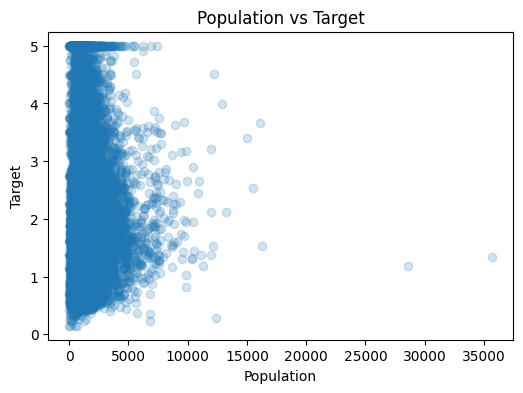

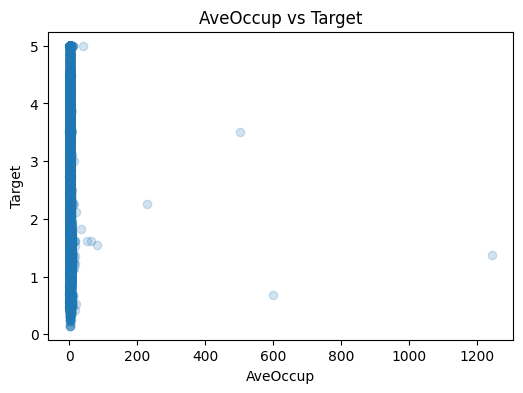

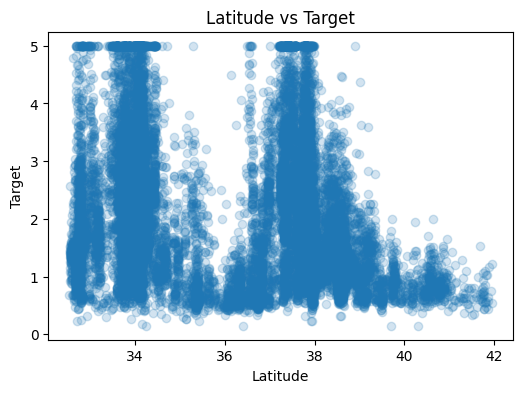

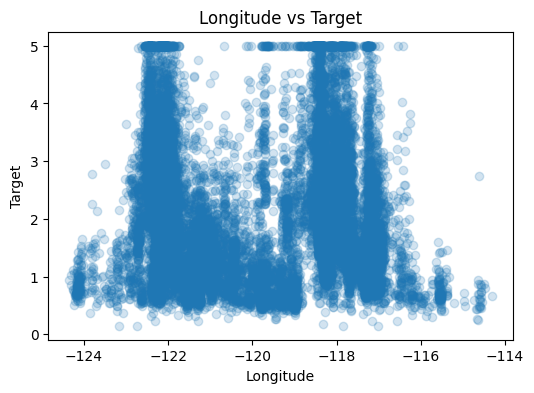

In [24]:
for col in x.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(x[col], y, alpha=0.2)
    plt.xlabel(col)
    plt.ylabel("Target")
    plt.title(f"{col} vs Target")
    plt.show()

In [25]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state= 42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [26]:
w1 = LR_closed(x_train , y_train)
w1

array([-3.70232777e+01,  4.48674910e-01,  9.72425752e-03, -1.23323343e-01,
        7.83144907e-01, -2.02962058e-06, -3.52631849e-03, -4.19792487e-01,
       -4.33708065e-01])

In [27]:
y_pred = h_w(x_test , w1)
print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [28]:
mse = MSE(x_test, w1, y_test)
rmse = RMSE(x_test, w1, y_test)
mae = MAE(x_test, w1, y_test)
r2 = R2(x_test, w1, y_test)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.5558915986954799
RMSE: 0.7455813830129343
MAE : 0.5332001304959605
R²  : 0.575787706032271


In [29]:
print("Train R²:", R2(x_train.values, w1, y_train))
print("Test R² :", R2(x_test.values, w1, y_test))

Train R²: 0.6125511913966952
Test R² : 0.575787706032271


In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train , y_train)
y_new = lr.predict(x_test)
y_new

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

In [31]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score 

mse = mean_squared_error(y_test , y_new)
mse = mean_squared_error(y_test, y_new)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_new)
r2 = r2_score(y_test, y_new)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.5558915986952442
RMSE: 0.7455813830127763
MAE : 0.5332001304956555
R²  : 0.575787706032451


In [32]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [34]:
copy = x
copy = copy.drop(['Latitude' , 'Longitude'] , axis=1)
copy_train , copy_test , copy_ans_train , copy_ans_test = train_test_split(copy, y , test_size=0.2 , random_state = 42)
lr.fit(copy_train , copy_ans_train)
copy_ans_pred = lr.predict(copy_test)
mse = mean_squared_error(copy_ans_pred , copy_ans_test)
rmse = np.sqrt(mse)
r2 = r2_score(copy_ans_test , copy_ans_pred)
mae = mean_absolute_error(copy_ans_test , copy_ans_pred)
print(f'''MSE : {mse}
RMSE = {rmse}
MAE = {mae}
R2 = {r2}
''')

MSE : 0.6421872314534857
RMSE = 0.8013658536857468
MAE = 0.5792140665454438
R2 = 0.5099337366296426



# Linear Regression — Feature Selection Experiment on California Housing

## Feature Selection Experiment

After implementing Linear Regression from scratch and testing it on the California Housing dataset, an additional experiment was performed to investigate the effect of removing features from the dataset.

The purpose of this experiment was to understand whether using all available features always leads to better performance.

The original California Housing dataset contains several features related to housing and the geographical characteristics of the area.

The Linear Regression model was first trained using the complete set of features.

The model was then trained again after removing two features.

---

## 1. Baseline Model

The first model used all available features.

The workflow was:

```text
California Housing Dataset
        ↓
Train/Test Split
        ↓
Linear Regression From Scratch
        ↓
Prediction
        ↓
MSE / RMSE / MAE / R²
```

The baseline model achieved approximately:

* MSE: `0.5559`
* RMSE: `0.7456`
* MAE: `0.5332`
* R²: `0.5758`

The R² value indicates that the Linear Regression model explains approximately 57.6% of the variance in the target variable on the test set.

---

## 2. Removing Two Features

Two features were removed from the dataset and the Linear Regression model was trained again.

The purpose was not simply to improve the model, but to experimentally investigate the effect of feature selection.

After removing features, the same training and evaluation procedure was used.

The important point is that the comparison should be made using the same:

* Train/Test split
* Random state
* Evaluation metrics
* Linear Regression implementation

This ensures that the difference in performance can mainly be attributed to the change in the feature set.

---

## 3. Comparing the Results

The results of the two experiments can be compared using a table such as:

| Model    | Features             |    MSE |   RMSE |    MAE |     R² |
| -------- | -------------------- | -----: | -----: | -----: | -----: |
| Baseline | All Features         | 0.5559 | 0.7456 | 0.5332 | 0.5758 |
| Reduced  | Two Features Removed | 0.6421 | 0.8013 | 0.5792 | 0.5099 |

The values for the second model should be filled in after running the experiment.

---

## 4. What Does the Comparison Tell Us?

If removing the two features decreases the performance, it suggests that those features contained useful information for predicting the target.

If the performance remains almost unchanged, the removed features may have contributed little additional information to the Linear Regression model.

If the performance improves, the removed features may have introduced noise or redundant information that negatively affected the model.

Therefore, having more features does not automatically guarantee better performance.

Feature selection is an important part of machine-learning preprocessing and model development.

---

## 5. Important Lesson

This experiment demonstrates an important practical machine-learning principle:

> More features do not necessarily mean a better model.

The usefulness of a feature depends on how much relevant information it provides to the model.

Feature selection can be used to:

* Remove irrelevant features
* Reduce dimensionality
* Reduce noise
* Make models simpler
* Improve interpretability
* Potentially improve generalization

However, removing features should be based on experimentation and proper evaluation rather than assumptions.

---

## 6. Conclusion

The California Housing experiment showed how changing the feature set can affect Linear Regression performance.

Instead of assuming that every available feature is useful, different feature combinations can be tested and evaluated objectively.

This experiment also introduced the idea of **Feature Selection**, which will later become an important part of the machine-learning preprocessing and model-development workflow.
